In [18]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
from datetime import datetime
#from statsmodels.tsa.arima_model import ARIMA
from pmdarima import auto_arima

In [19]:
# Transformação dos atributos que estão no formato string em formato de data.

data = pd.read_csv('C:/Users/mrwag/OneDrive/Big Data/DS/21.Textos/airpassengers.csv', parse_dates= ['Month'],
                   index_col='Month', date_format='%Y-%m')
data


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


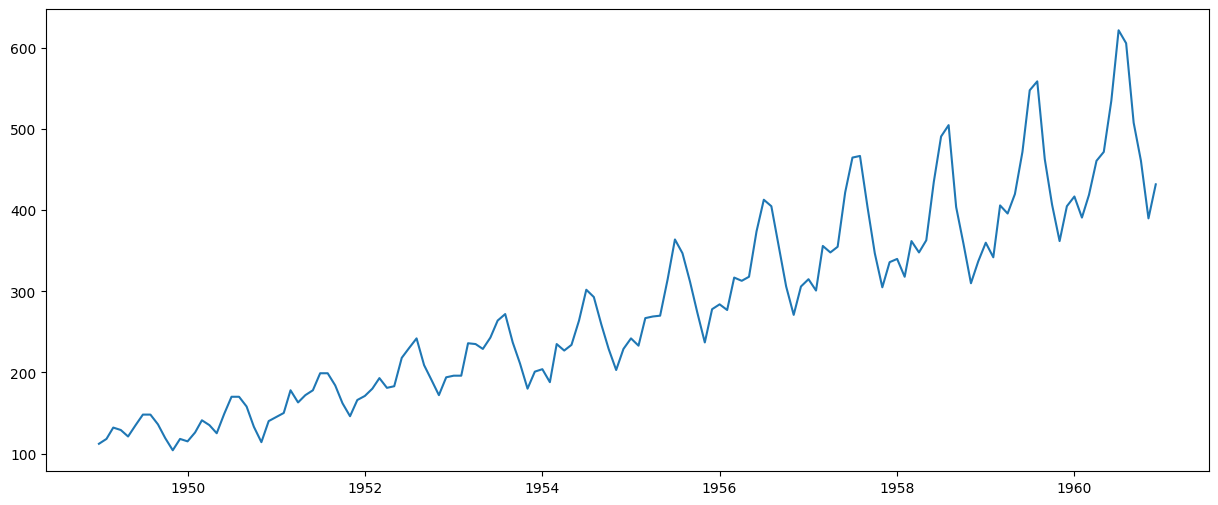

In [20]:
# Visualização dos dados.

plt.plot(data)

In [24]:
stepwise_model = auto_arima(y = data, start_p = 1, start_q = 1, start_d = 0, start_P = 0, 
                            max_p = 6, max_q = 6, m  = 12, seasonal = True, trace = True, stepwise = True) 

# AIC é uma métrica que avalia o quanto o método é bom.

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1022.896, Time=0.26 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.10 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.03 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.17 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.28 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.20 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.14 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.21 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.27 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.20 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.11 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.13 sec
 ARIMA(0,1,1)(1,1,1)[12]     

In [ ]:
print(stepwise_model.summary()) # aqui eu vejo todos os detalhes de uma vez.

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Thu, 23 Apr 2026   AIC                           1019.178
Time:                                     09:39:29   BIC                           1030.679
Sample:                                 01-01-1949   HQIC                          1023.851
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      

In [26]:
train = data.loc['1949-01-01':'1959-12-01']
test = data.loc['1960-01-01':]

In [27]:
train

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1959-08-01,559
1959-09-01,463
1959-10-01,407


In [28]:
test

,#Passengers
Month,
1960-01-01,417
1960-02-01,391
1960-03-01,419
1960-04-01,461
1960-05-01,472
1960-06-01,535
1960-07-01,622
1960-08-01,606
1960-09-01,508


In [29]:
stepwise_model.fit(train)

,order,"(0, ...)"
,seasonal_order,"(2, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,False


In [30]:
future_forecast = stepwise_model.predict(n_periods=12)
future_forecast

1960-01-01    421.153373
1960-02-01    401.605753
1960-03-01    462.083577
1960-04-01    450.826710
1960-05-01    475.124360
1960-06-01    529.774275
1960-07-01    605.741141
1960-08-01    618.774117
1960-09-01    516.769043
1960-10-01    463.571231
1960-11-01    417.168988
1960-12-01    458.049056
Freq: MS, dtype: float64

In [31]:
future_forecast = pd.DataFrame(future_forecast, index = test.index, columns = ['#Passengers'])


<Axes: xlabel='Month'>

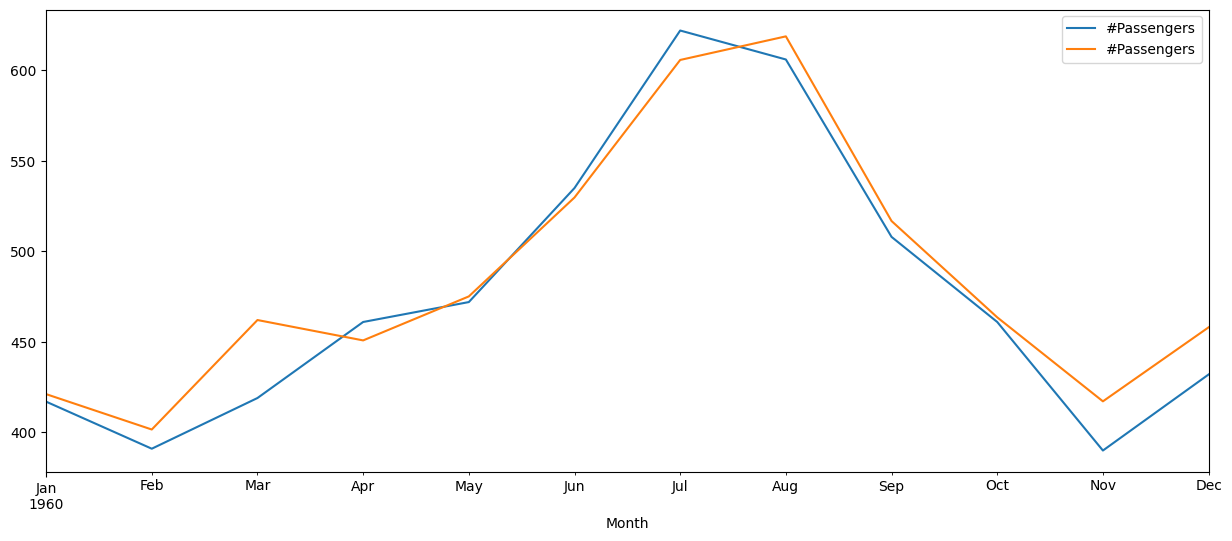

In [32]:
# Azul test laranja forecast.

pd.concat([test, future_forecast], axis = 1).plot()

<Axes: xlabel='Month'>

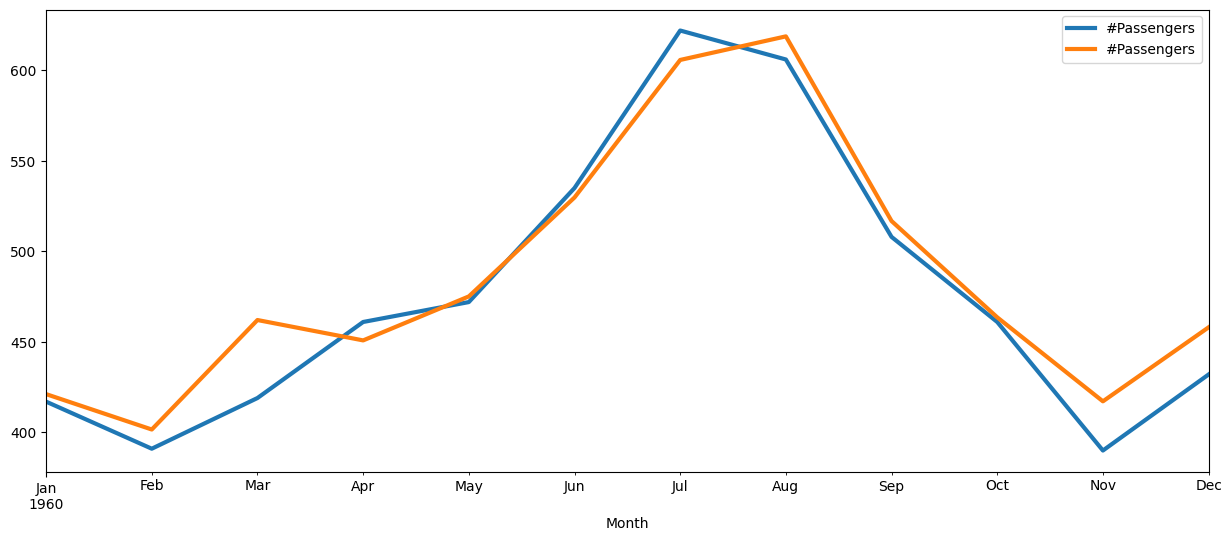

In [33]:
pd.concat([test, future_forecast], axis = 1).plot(linewidth = 3)